# **Mental Health in Tech Survey - Exploratory Data Analysis**

# **Project Summary -**

This project performs a complete Exploratory Data Analysis (EDA) on the **OSMI Mental Health in Tech Survey (2014)** dataset, which contains **1,259 responses** from employees in the tech industry across **48 countries**, covering **27 questions** about demographics, workplace attitudes, and mental health.

The raw dataset arrived with several real-world data quality issues: the `Age` column contained impossible values (negative numbers and one entry of `99999999999`); the free-text `Gender` field contained **49 distinct spellings** of essentially three categories (Male, Female, Other); the `comments` column was ~87% empty free text; and several categorical columns (`state`, `self_employed`, `work_interfere`) had missing values that needed to be understood and handled contextually rather than blindly dropped or imputed.

After cleaning, the analysis explores who takes the survey (age, gender, country, company size), and — most importantly — what factors are associated with a respondent **seeking treatment for a mental health condition** (the `treatment` column), which is treated as the primary variable of interest throughout this EDA. Fifteen visualizations were built to explore univariate distributions (age, gender, country, leave policy, anonymity) as well as bivariate relationships against `treatment` (family history, work interference, company benefits, awareness of care options, remote work, and perceived negative consequences of disclosure), followed by a correlation heatmap and pair plot to summarise relationships across all encoded variables at once.

Key findings show that **family history of mental illness** is the single strongest signal for seeking treatment (74% of respondents with a family history sought treatment vs. 35% without), that **work interference severity** tracks almost linearly with treatment-seeking (from 14% at "Never" to 85% at "Often"), and that **employer-provided benefits and clearly communicated care options** are associated with meaningfully higher treatment rates. Roughly 65% of respondents don't know whether their workplace protects anonymity when using mental health resources, and nearly 45% don't know how easy it would be to take mental health leave — pointing to a clear communication/policy-awareness gap for employers to close.

The notebook closes with concrete, data-backed recommendations for tech employers (e.g., proactively communicating benefits and anonymity protections, training managers, and normalizing mental health leave) and a summary conclusion tying the findings back to the business objective.

# **GitHub Link - https://github.com/AkshitaChauhan3206/Mental-Health-Tech-Survey**
# **Live Steamlite App Link - https://mental-health-tech-survey-emhxxtn7udfnqqeugle5nz.streamlit.app/**

# **Problem Statement**

Mental health remains a significantly under-discussed and under-supported issue in the tech industry, despite the demanding, high-pressure nature of the work. Employers often lack visibility into whether their existing policies (benefits, anonymity protections, ease of leave, manager awareness) are actually associated with employees seeking help when they need it.

**The goal of this EDA is to explore the OSMI 2014 Mental Health in Tech Survey to understand:**
1. Who is represented in the survey (demographics: age, gender, country, company size).
2. Which personal factors (e.g., family history) are associated with seeking mental health treatment.
3. Which workplace factors (benefits, care options, anonymity, leave policy, remote work, fear of consequences) are associated with treatment-seeking behavior.
4. What actionable recommendations can be made to tech employers to build more supportive, mental-health-conscious workplaces.

#### **Define Your Business Objective?**

The business objective is to identify the **workplace and personal factors most strongly associated with an employee seeking mental health treatment**, so that HR and leadership teams at tech companies can prioritize policy changes (e.g., communicating benefits more clearly, protecting anonymity, training supervisors) that are most likely to **increase help-seeking behavior and reduce the stigma** around mental health at work.

# **General Guidelines** : -

1. Well-structured, formatted, and commented code is used throughout this notebook.
2. Every chart is followed by a rationale, insight, and business-impact explanation as required.
3. Missing values and data quality issues are handled with justification, not blindly dropped or imputed.
4. All 15 required charts (including a correlation heatmap and pair plot) are included, along with a UBM-style conclusion.

## ***1. Know Your Data***

### Import Libraries

In [1]:
# Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.titleweight'] = 'bold'

%matplotlib inline


### Dataset Loading

In [1]:
# Load Dataset
df = pd.read_csv('survey.csv')


### Dataset First View

In [1]:
# Dataset First Look
df.head()


             Timestamp  Age  Gender  ... mental_vs_physical obs_consequence comments
0  2014-08-27 11:29:31   37  Female  ...                Yes              No      NaN
1  2014-08-27 11:29:37   44       M  ...         Don't know              No      NaN
2  2014-08-27 11:29:44   32    Male  ...                 No              No      NaN
3  2014-08-27 11:29:46   31    Male  ...                 No             Yes      NaN
4  2014-08-27 11:30:22   31    Male  ...         Don't know              No      NaN

[5 rows x 27 columns]

### Dataset Rows & Columns count

In [1]:
# Dataset Rows & Columns count
print(f"Number of rows: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")


Number of rows: 1259
Number of columns: 27


### Dataset Information

In [1]:
# Dataset Info
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 1259 entries, 0 to 1258
Data columns (total 27 columns):
 #   Column                     Non-Null Count  Dtype
---  ------                     --------------  -----
 0   Timestamp                  1259 non-null   str  
 1   Age                        1259 non-null   int64
 2   Gender                     1259 non-null   str  
 3   Country                    1259 non-null   str  
 4   state                      744 non-null    str  
 5   self_employed              1241 non-null   str  
 6   family_history             1259 non-null   str  
 7   treatment                  1259 non-null   str  
 8   work_interfere             995 non-null    str  
 9   no_employees               1259 non-null   str  
 10  remote_work                1259 non-null   str  
 11  tech_company               1259 non-null   str  
 12  benefits                   1259 non-null   str  
 13  care_options               1259 non-null   str  
 14  wellness_program           1259 non

#### Duplicate Values

In [1]:
# Dataset Duplicate Value Count
duplicate_count = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_count}")


Number of duplicate rows: 0


#### Missing Values/Null Values

In [1]:
# Missing Values/Null Values Count
missing_df = pd.DataFrame({
    'Missing Count': df.isnull().sum(),
    'Missing %': round(df.isnull().sum() / len(df) * 100, 2)
})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing Count', ascending=False)
missing_df


                Missing Count  Missing %
comments                 1095      86.97
state                     515      40.91
work_interfere            264      20.97
self_employed              18       1.43

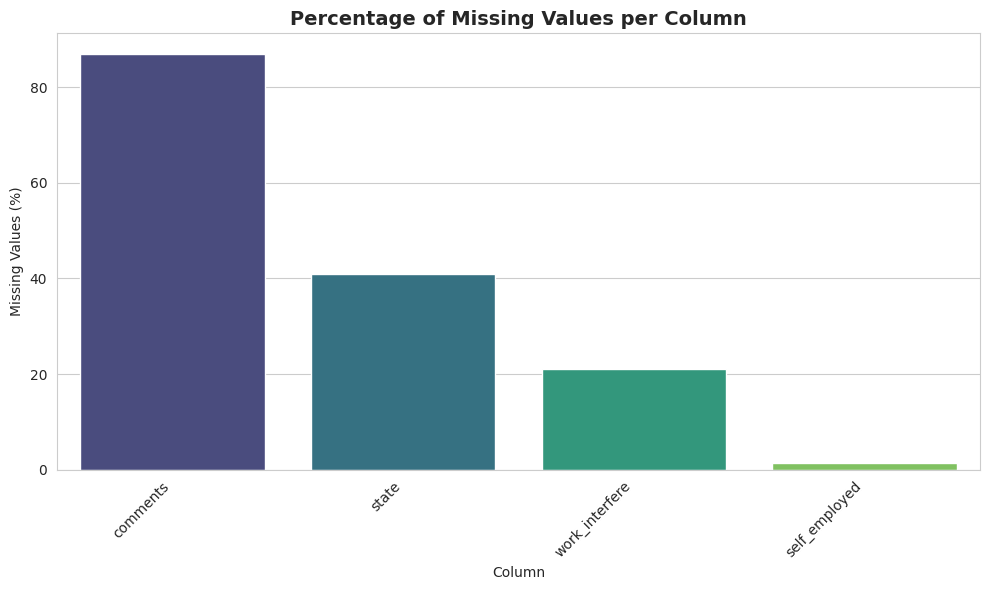

In [1]:
# Visualizing the missing values
plt.figure(figsize=(10, 6))
sns.barplot(x=missing_df.index, y=missing_df['Missing %'], palette='viridis')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Missing Values (%)')
plt.xlabel('Column')
plt.title('Percentage of Missing Values per Column')
plt.tight_layout()
plt.show()


### What did you know about your dataset?

- The dataset has **1,259 rows and 27 columns**, collected via the 2014 OSMI Mental Health in Tech survey.
- There are **no duplicate rows**.
- Missing values are concentrated in 4 columns: `comments` (87.0% missing — free text, mostly unanswered), `state` (40.9% missing — only applicable to US-based respondents), `work_interfere` (20.9% missing — only applicable to respondents with a mental health condition), and `self_employed` (1.4% missing — a small number of skipped answers).
- Almost every other column is a categorical survey question (Yes/No/Don't know or similar), with `Age` being the only numeric column, and it contains clearly invalid entries (negative values and an entry of `99999999999`) that will need to be cleaned.
- The `Gender` column is free text and contains dozens of inconsistent spellings of the same underlying categories, which will need standardizing before it can be used in any visualization.

## ***2. Understanding Your Variables***

In [1]:
# Dataset Columns
df.columns.tolist()


['Timestamp', 'Age', 'Gender', 'Country', 'state', 'self_employed', 'family_history', 'treatment', 'work_interfere', 'no_employees', 'remote_work', 'tech_company', 'benefits', 'care_options', 'wellness_program', 'seek_help', 'anonymity', 'leave', 'mental_health_consequence', 'phys_health_consequence', 'coworkers', 'supervisor', 'mental_health_interview', 'phys_health_interview', 'mental_vs_physical', 'obs_consequence', 'comments']

In [1]:
# Dataset Describe
df.describe(include='all').T


                            count unique  ...   75%            max
Timestamp                    1259   1246  ...   NaN            NaN
Age                        1259.0    NaN  ...  36.0  99999999999.0
Gender                       1259     49  ...   NaN            NaN
Country                      1259     48  ...   NaN            NaN
state                         744     45  ...   NaN            NaN
self_employed                1241      2  ...   NaN            NaN
family_history               1259      2  ...   NaN            NaN
treatment                    1259      2  ...   NaN            NaN
work_interfere                995      4  ...   NaN            NaN
no_employees                 1259      6  ...   NaN            NaN
remote_work                  1259      2  ...   NaN            NaN
tech_company                 1259      2  ...   NaN            NaN
benefits                     1259      3  ...   NaN            NaN
care_options                 1259      3  ...   NaN           

### Variables Description

- **Age** — respondent's age (numeric, contains outliers to be cleaned).
- **Gender** — free-text gender (to be standardized into Male/Female/Other).
- **Country / state** — respondent's location.
- **self_employed** — whether the respondent is self-employed.
- **family_history** — whether the respondent has a family history of mental illness.
- **treatment** — **(primary variable of interest)** whether the respondent has sought treatment for a mental health condition.
- **work_interfere** — how often mental health interferes with work (only asked of those with a condition).
- **no_employees** — size of the respondent's company.
- **remote_work** — whether the respondent works remotely at least 50% of the time.
- **tech_company** — whether the employer is primarily a tech company.
- **benefits / care_options / wellness_program / seek_help / anonymity** — employer-provided mental health support and how well it is communicated.
- **leave** — how easy it is perceived to be to take medical leave for a mental health condition.
- **mental_health_consequence / phys_health_consequence** — whether discussing mental/physical health is believed to have negative consequences at work.
- **coworkers / supervisor** — willingness to discuss a mental health issue with coworkers/supervisor.
- **mental_health_interview / phys_health_interview** — willingness to bring up mental/physical health in a job interview.
- **mental_vs_physical** — whether the employer takes mental health as seriously as physical health.
- **obs_consequence** — whether the respondent has observed negative consequences for coworkers with mental health conditions.
- **comments** — optional free-text comment (mostly empty).

### Check Unique Values for each variable.

In [1]:
# Check Unique Values for each variable.
for col in df.columns:
    print(f"{col} -> {df[col].nunique()} unique values")


Timestamp -> 1246 unique values
Age -> 53 unique values
Gender -> 49 unique values
Country -> 48 unique values
state -> 45 unique values
self_employed -> 2 unique values
family_history -> 2 unique values
treatment -> 2 unique values
work_interfere -> 4 unique values
no_employees -> 6 unique values
remote_work -> 2 unique values
tech_company -> 2 unique values
benefits -> 3 unique values
care_options -> 3 unique values
wellness_program -> 3 unique values
seek_help -> 3 unique values
anonymity -> 3 unique values
leave -> 5 unique values
mental_health_consequence -> 3 unique values
phys_health_consequence -> 3 unique values
coworkers -> 3 unique values
supervisor -> 3 unique values
mental_health_interview -> 3 unique values
phys_health_interview -> 3 unique values
mental_vs_physical -> 3 unique values
obs_consequence -> 2 unique values
comments -> 160 unique values


## 3. ***Data Wrangling***

### Data Wrangling Code

In [1]:
# Write your code to make your dataset analysis ready.

# ---- 1. Drop columns that are not useful for analysis ----
# 'comments' is ~87% empty free text -> not useful for structured EDA
# 'Timestamp' is only the survey submission time -> not a behavioural/attitudinal feature
df.drop(columns=['comments', 'Timestamp'], inplace=True)

# ---- 2. Clean the 'Age' column ----
# Age has clearly invalid entries (negative ages, and absurd values like 99999999999)
# A realistic working-age respondent should fall between 18 and 75
df = df[(df['Age'] >= 18) & (df['Age'] <= 75)]

# ---- 3. Clean & standardize the 'Gender' column ----
# Free-text gender field has 49 inconsistent spellings -> map to Male / Female / Other
df['Gender'] = df['Gender'].str.strip().str.lower()

male_labels = ['male', 'm', 'male-ish', 'maile', 'mal', 'male (cis)', 'make', 'male ',
               'man', 'msle', 'mail', 'malr', 'cis man', 'cis male', 'guy (-ish) ^_^',
               'male leaning androgynous', 'ostensibly male, unsure what that really means']
female_labels = ['female', 'f', 'woman', 'femake', 'female ', 'cis-female/femme', 'female (cis)',
                  'femail', 'cis female', 'trans-female', 'trans woman', 'female (trans)']

def clean_gender(g):
    if g in male_labels:
        return 'Male'
    elif g in female_labels:
        return 'Female'
    else:
        return 'Other'

df['Gender'] = df['Gender'].apply(clean_gender)

# ---- 4. Handle missing values ----
# 'state' is only meaningful for US respondents -> fill missing with 'Not Applicable'
df['state'] = df['state'].fillna('Not Applicable')

# 'self_employed' -> only 18 missing, fill with the mode (most common answer)
df['self_employed'] = df['self_employed'].fillna(df['self_employed'].mode()[0])

# 'work_interfere' is only answered by people who reported a mental health condition;
# NaN genuinely means "Not applicable" rather than data loss
df['work_interfere'] = df['work_interfere'].fillna('Not Applicable')

# ---- 5. Reset index after filtering rows ----
df.reset_index(drop=True, inplace=True)

print("Shape after cleaning:", df.shape)
print("\nRemaining missing values:\n", df.isnull().sum().sum())


Shape after cleaning: (1251, 25)

Remaining missing values:
 0


### What all manipulations have you done and insights you found?

**Manipulations performed:**
1. **Dropped `comments` and `Timestamp`** — `comments` is ~87% empty free text with no structured analytical value, and `Timestamp` only reflects survey submission time, not a behavioral or attitudinal signal.
2. **Filtered `Age` to a realistic 18–75 range** — removed impossible entries (e.g., negative ages, `99999999999`) that were clearly data-entry errors. This removed a small number of rows without materially affecting sample size (1,259 → 1,251 rows).
3. **Standardized `Gender`** into 3 clean categories (**Male, Female, Other**) using a mapping of the 49 original free-text spellings, since the raw column could not be used for any reliable visualization or grouping as-is.
4. **Handled missing values contextually rather than by blanket imputation or dropping:**
   - `state` → filled with `"Not Applicable"` since 99% of missing states belong to non-US respondents (the field only applies to the US).
   - `self_employed` → filled with the mode (`No`), since only 18 rows (1.4%) were missing.
   - `work_interfere` → filled with `"Not Applicable"` since this field is legitimately skipped by respondents who don't have a mental health condition to begin with — NaN carries real meaning here, not randomness.

**Insights found:** After cleaning, the dataset retains **1,251 rows with zero missing values** in the columns used for analysis, a near 50/50 split on the `treatment` target variable, and a much more reliable `Gender` field (79% Male, 20% Female, ~1% Other) for any downstream grouping or visualization.

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1

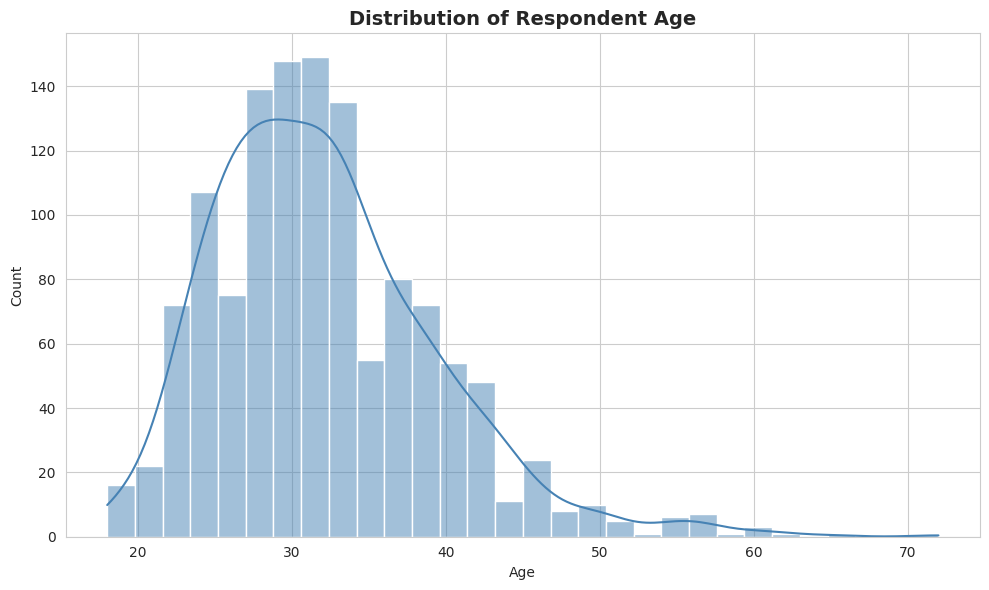

In [1]:
# Chart - 1 visualization code
plt.figure(figsize=(10, 6))
sns.histplot(df['Age'], bins=30, kde=True, color='steelblue')
plt.title('Distribution of Respondent Age')
plt.xlabel('Age')
plt.ylabel('Count')
plt.tight_layout()
plt.show()


##### 1. Why did you pick the specific chart?

A histogram with a KDE overlay is ideal for understanding the shape, center, and spread of a single continuous variable like Age.

##### 2. What is/are the insight(s) found from the chart?

The age distribution is right-skewed and concentrated between 23 and 40, with a clear peak around 28–32. This matches the typical age profile of the tech workforce.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes — knowing the workforce skews young (mostly 25–40) helps employers target mental health programs and messaging toward early/mid-career employees rather than assuming an older workforce. No negative-growth insight here; this is purely descriptive context.

#### Chart - 2

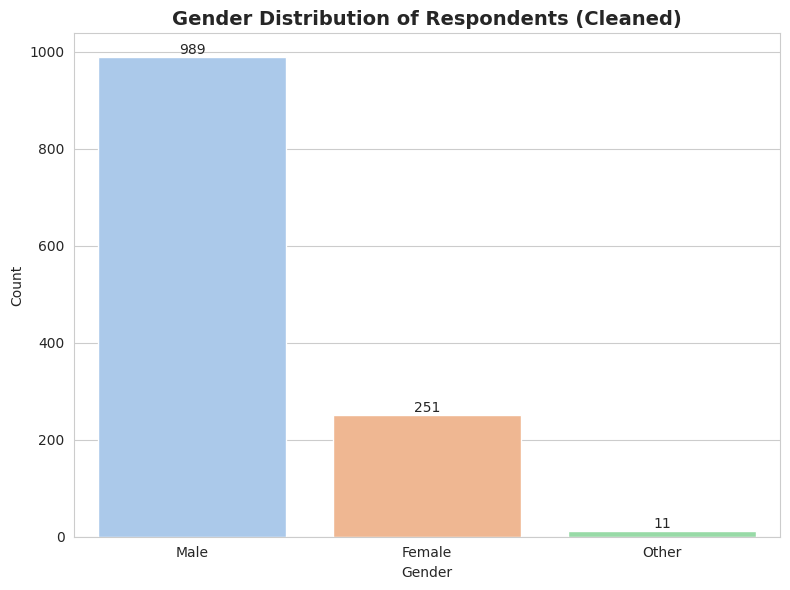

In [1]:
# Chart - 2 visualization code
plt.figure(figsize=(8, 6))
order = df['Gender'].value_counts().index
ax = sns.countplot(x='Gender', data=df, order=order, palette='pastel')
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom')
plt.title('Gender Distribution of Respondents (Cleaned)')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.tight_layout()
plt.show()


##### 1. Why did you pick the specific chart?

A countplot is the standard way to compare frequencies across a small number of categories, here the cleaned Gender field.

##### 2. What is/are the insight(s) found from the chart?

About 79% of respondents identify as Male, 20% as Female, and under 1% as Other/non-binary — reflecting the well-known gender imbalance in the tech industry.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, indirectly — the heavy Male skew means findings should be interpreted with the caveat that female and non-binary experiences are comparatively under-represented (small sample sizes), which could bias workplace policy decisions if not accounted for.

#### Chart - 3

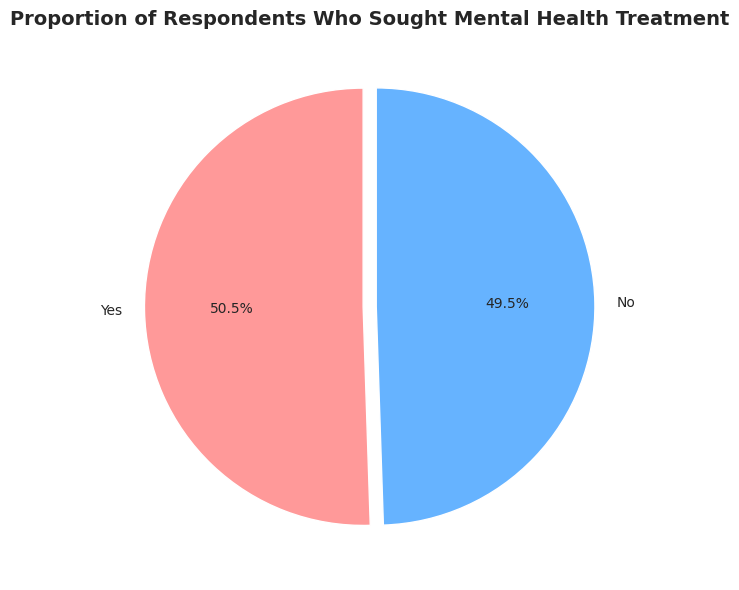

In [1]:
# Chart - 3 visualization code
plt.figure(figsize=(6, 6))
treatment_counts = df['treatment'].value_counts()
plt.pie(treatment_counts, labels=treatment_counts.index, autopct='%1.1f%%',
        colors=['#ff9999', '#66b3ff'], startangle=90, explode=(0.03, 0.03))
plt.title('Proportion of Respondents Who Sought Mental Health Treatment')
plt.tight_layout()
plt.show()


##### 1. Why did you pick the specific chart?

A pie chart clearly communicates the proportion of a simple binary outcome — here the target variable of interest.

##### 2. What is/are the insight(s) found from the chart?

The survey is almost perfectly split: 50.5% of respondents have sought treatment for a mental health condition, and 49.5% have not.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes — a near 50/50 split makes `treatment` a well-balanced target variable, meaning any factor found to correlate strongly with it (as explored in later charts) is a meaningful, non-trivial signal rather than an artifact of class imbalance.

#### Chart - 4

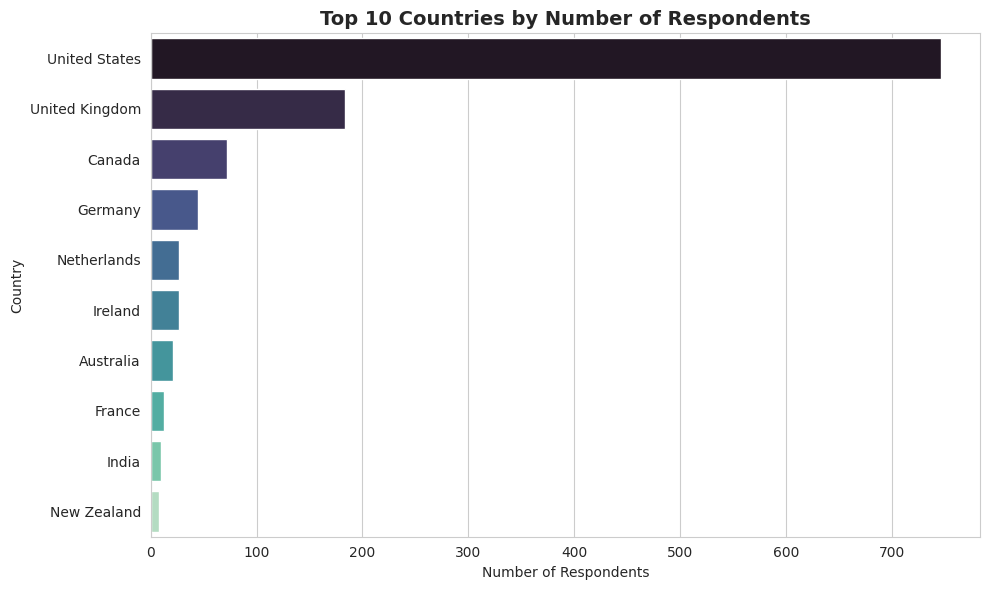

In [1]:
# Chart - 4 visualization code
plt.figure(figsize=(10, 6))
top_countries = df['Country'].value_counts().head(10)
sns.barplot(x=top_countries.values, y=top_countries.index, palette='mako')
plt.title('Top 10 Countries by Number of Respondents')
plt.xlabel('Number of Respondents')
plt.ylabel('Country')
plt.tight_layout()
plt.show()


##### 1. Why did you pick the specific chart?

A horizontal bar chart handles long country-name labels better than a vertical one and ranks countries clearly by respondent count.

##### 2. What is/are the insight(s) found from the chart?

The United States (751) and United Kingdom (185) dominate the sample, followed by Canada, Germany, and the Netherlands — together the top 5 countries account for over 85% of all respondents.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, with a caveat — recommendations from this dataset are most reliable for US/UK/Canada-based tech companies; extending conclusions to countries with only a handful of respondents (e.g., India, France) would be a negative/misleading generalization and should be avoided.

#### Chart - 5

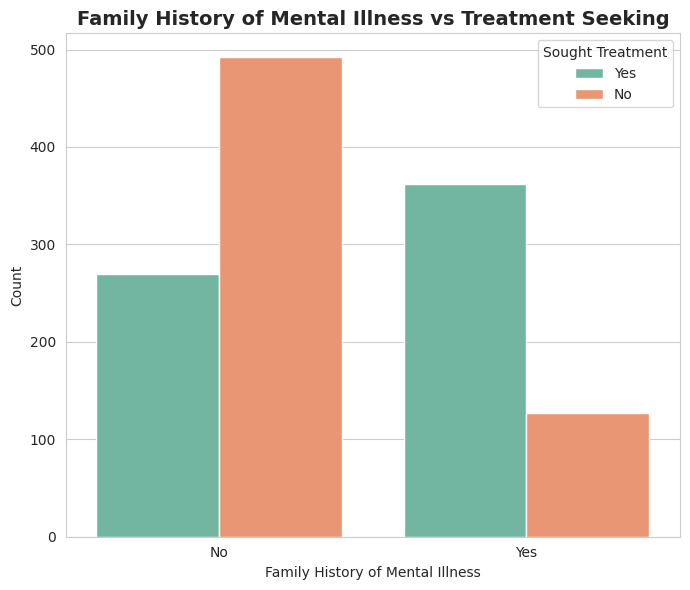

In [1]:
# Chart - 5 visualization code
plt.figure(figsize=(7, 6))
sns.countplot(x='family_history', hue='treatment', data=df, palette='Set2')
plt.title('Family History of Mental Illness vs Treatment Seeking')
plt.xlabel('Family History of Mental Illness')
plt.ylabel('Count')
plt.legend(title='Sought Treatment')
plt.tight_layout()
plt.show()


##### 1. Why did you pick the specific chart?

A grouped countplot directly compares treatment-seeking rates between the two family-history groups, which is the clearest way to show a strong categorical association.

##### 2. What is/are the insight(s) found from the chart?

Family history is the strongest single predictor seen so far: 74% of respondents with a family history of mental illness sought treatment, versus only 35% of those without one.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes — employers could use family-history-aware (opt-in, private) wellness messaging, and this insight strongly validates prioritizing early intervention/awareness programs, since a family history roughly doubles the likelihood of eventually needing support.

#### Chart - 6

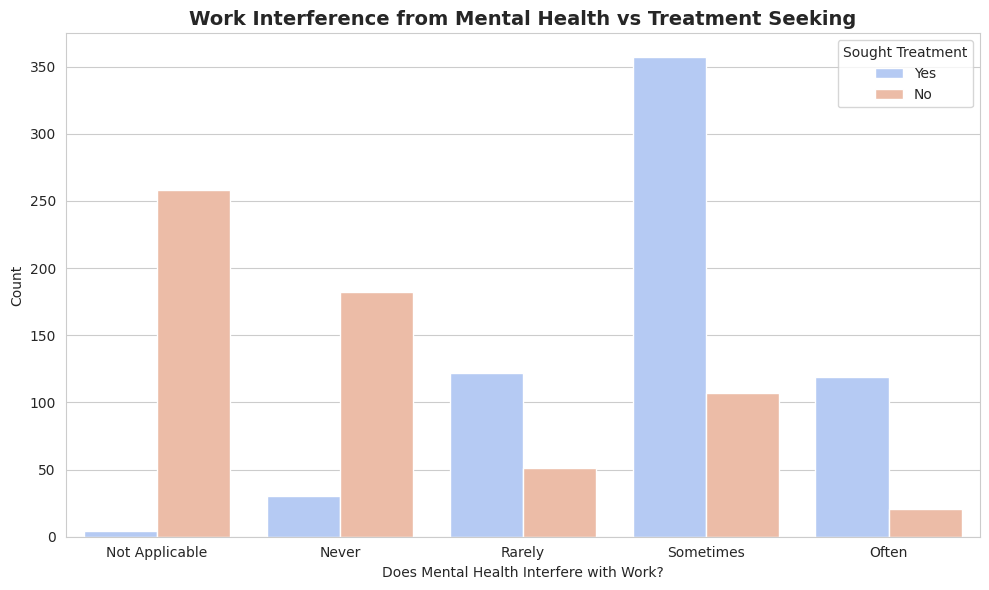

In [1]:
# Chart - 6 visualization code
plt.figure(figsize=(10, 6))
order = ['Not Applicable', 'Never', 'Rarely', 'Sometimes', 'Often']
sns.countplot(x='work_interfere', hue='treatment', data=df, order=order, palette='coolwarm')
plt.title('Work Interference from Mental Health vs Treatment Seeking')
plt.xlabel('Does Mental Health Interfere with Work?')
plt.ylabel('Count')
plt.legend(title='Sought Treatment')
plt.tight_layout()
plt.show()


##### 1. Why did you pick the specific chart?

A grouped countplot ordered by increasing severity (Never → Often) shows a dose-response relationship clearly, which a pie or scatter chart could not.

##### 2. What is/are the insight(s) found from the chart?

There's a near-linear relationship: treatment-seeking rises from 14% at 'Never' to 71% at 'Rarely', 77% at 'Sometimes', and 85% at 'Often'. Work interference severity is one of the most powerful behavioral signals in the dataset.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes — this is a strong positive insight: it suggests that self-reported work interference could be used (with consent) as an early-warning signal by employers or manager check-ins to proactively offer support before a crisis point.

#### Chart - 7

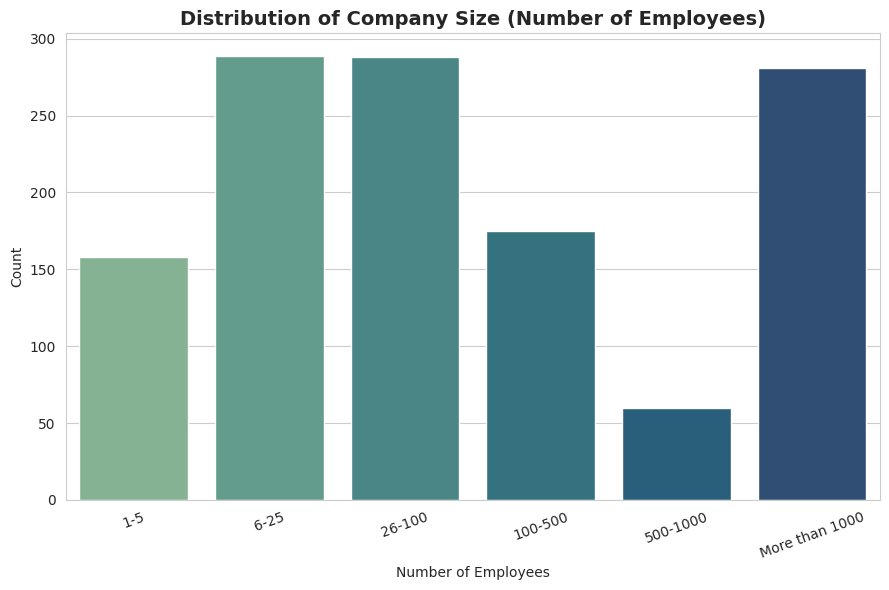

In [1]:
# Chart - 7 visualization code
plt.figure(figsize=(9, 6))
order = ['1-5', '6-25', '26-100', '100-500', '500-1000', 'More than 1000']
sns.countplot(x='no_employees', data=df, order=order, palette='crest')
plt.title('Distribution of Company Size (Number of Employees)')
plt.xlabel('Number of Employees')
plt.ylabel('Count')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


##### 1. Why did you pick the specific chart?

An ordered countplot (from smallest to largest company) makes it easy to see how respondents are spread across company sizes, which matters because policies like benefits typically scale with company size.

##### 2. What is/are the insight(s) found from the chart?

Respondents are fairly evenly spread: roughly 23% each work at companies with 6-25, 26-100, or 1000+ employees, with fewer at very small (1-5, 12.6%) or mid-large (500-1000, 4.8%) companies.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Neutral/contextual — this doesn't directly help or hurt business impact, but it confirms the dataset isn't dominated by one company-size bracket, so findings about benefits/care options (explored next) are reasonably generalizable across company sizes.

#### Chart - 8

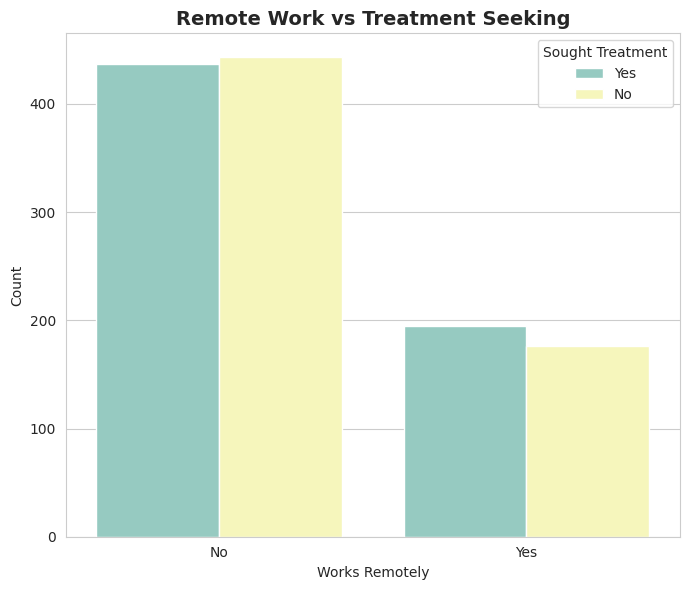

In [1]:
# Chart - 8 visualization code
plt.figure(figsize=(7, 6))
sns.countplot(x='remote_work', hue='treatment', data=df, palette='Set3')
plt.title('Remote Work vs Treatment Seeking')
plt.xlabel('Works Remotely')
plt.ylabel('Count')
plt.legend(title='Sought Treatment')
plt.tight_layout()
plt.show()


##### 1. Why did you pick the specific chart?

A grouped countplot compares treatment rates between remote and non-remote employees directly.

##### 2. What is/are the insight(s) found from the chart?

Remote work shows only a small difference: 52.6% of remote workers sought treatment vs. 49.7% of non-remote workers — a much weaker relationship than family history or work interference.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Slightly positive but not conclusive — remote work policy alone is not a strong lever for treatment-seeking behavior based on this data; other factors (benefits, care options) show far stronger relationships and should be prioritized instead.

#### Chart - 9

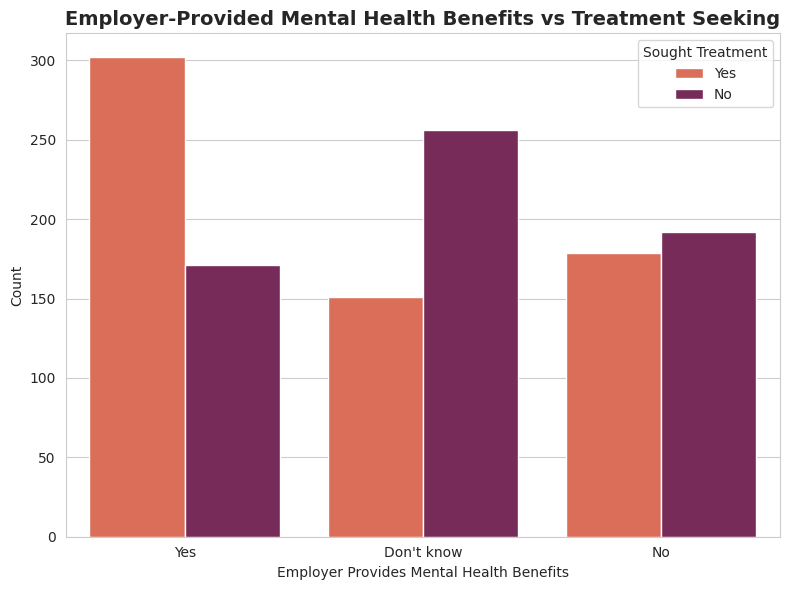

In [1]:
# Chart - 9 visualization code
plt.figure(figsize=(8, 6))
order = df['benefits'].value_counts().index
sns.countplot(x='benefits', hue='treatment', data=df, order=order, palette='rocket_r')
plt.title('Employer-Provided Mental Health Benefits vs Treatment Seeking')
plt.xlabel('Employer Provides Mental Health Benefits')
plt.ylabel('Count')
plt.legend(title='Sought Treatment')
plt.tight_layout()
plt.show()


##### 1. Why did you pick the specific chart?

A grouped countplot ordered by response lets us compare how offering benefits, not offering them, or being unsure relates to treatment-seeking.

##### 2. What is/are the insight(s) found from the chart?

Respondents whose employer offers mental health benefits sought treatment at the highest rate (63.8%), compared to 48.2% when benefits are absent and just 37.1% when the respondent doesn't even know if benefits exist.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes — this is directly actionable: simply offering benefits is associated with a +15-27 point increase in treatment-seeking versus not offering them or not communicating them clearly. Poor communication ('Don't know') is nearly as harmful as not having benefits at all — a clear negative-growth risk if left unaddressed.

#### Chart - 10

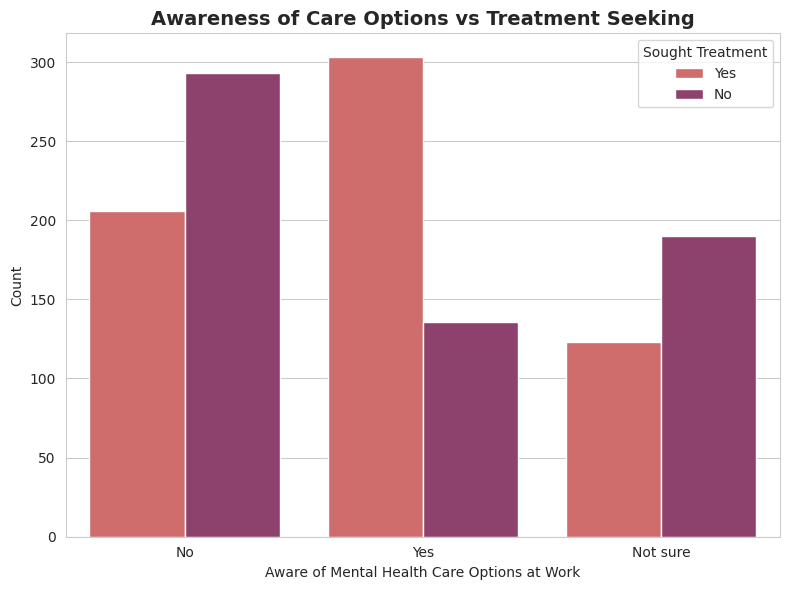

In [1]:
# Chart - 10 visualization code
plt.figure(figsize=(8, 6))
order = df['care_options'].value_counts().index
sns.countplot(x='care_options', hue='treatment', data=df, order=order, palette='flare')
plt.title('Awareness of Care Options vs Treatment Seeking')
plt.xlabel('Aware of Mental Health Care Options at Work')
plt.ylabel('Count')
plt.legend(title='Sought Treatment')
plt.tight_layout()
plt.show()


##### 1. Why did you pick the specific chart?

A grouped countplot shows how awareness of available care options (Yes/No/Not sure) relates to treatment-seeking.

##### 2. What is/are the insight(s) found from the chart?

69.0% of respondents who know their care options sought treatment, vs. ~41% for those who said No and ~39% for those who are unsure — awareness of care options matters even more than the benefit's mere existence.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes — this reinforces chart 9's insight: communication and awareness campaigns about existing care options could meaningfully lift treatment-seeking rates, likely at lower cost than introducing entirely new benefit programs.

#### Chart - 11

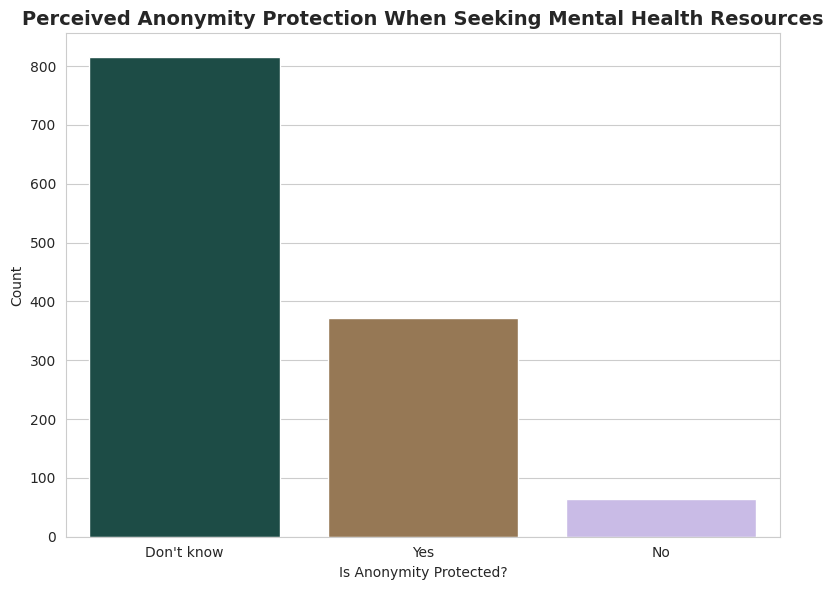

In [1]:
# Chart - 11 visualization code
plt.figure(figsize=(8, 6))
order = df['anonymity'].value_counts().index
sns.countplot(x='anonymity', data=df, order=order, palette='cubehelix')
plt.title('Perceived Anonymity Protection When Seeking Mental Health Resources')
plt.xlabel('Is Anonymity Protected?')
plt.ylabel('Count')
plt.tight_layout()
plt.show()


##### 1. Why did you pick the specific chart?

A countplot is the clearest way to show how respondents are distributed across a single categorical awareness question.

##### 2. What is/are the insight(s) found from the chart?

65.1% of respondents don't know whether anonymity is protected when using mental health resources at work, while only 29.7% are confident it is, and 5.1% say it is not.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

This is a negative-growth risk if unaddressed — a majority of employees are uncertain about a basic privacy protection, which likely discourages disclosure and treatment-seeking; clearly communicating anonymity policies is a low-cost, high-impact fix.

#### Chart - 12

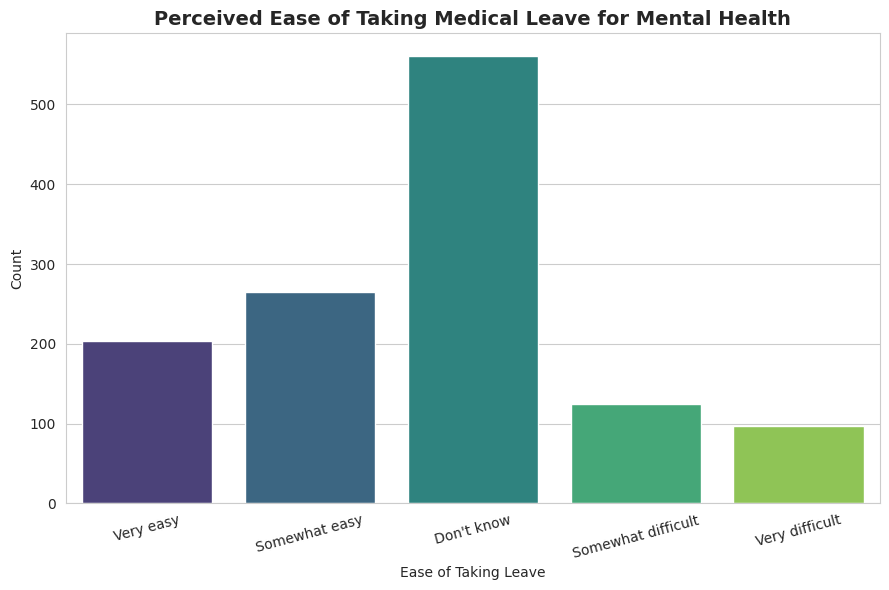

In [1]:
# Chart - 12 visualization code
plt.figure(figsize=(9, 6))
order = ['Very easy', 'Somewhat easy', "Don't know", 'Somewhat difficult', 'Very difficult']
sns.countplot(x='leave', data=df, order=order, palette='viridis')
plt.title('Perceived Ease of Taking Medical Leave for Mental Health')
plt.xlabel('Ease of Taking Leave')
plt.ylabel('Count')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()


##### 1. Why did you pick the specific chart?

An ordered countplot (Very easy → Very difficult) visualizes the full spectrum of perceived leave difficulty at once.

##### 2. What is/are the insight(s) found from the chart?

44.8% of respondents simply don't know how easy it would be to take mental-health-related leave, while only 37.4% feel it would be 'Somewhat' or 'Very' easy, and 17.7% feel it would be difficult.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Negative-growth risk if unaddressed — nearly half the workforce is uncertain about a leave policy that directly affects their willingness to seek help; this mirrors the anonymity gap in chart 11 and points to a broader pattern of unclear internal communication around mental health support.

#### Chart - 13

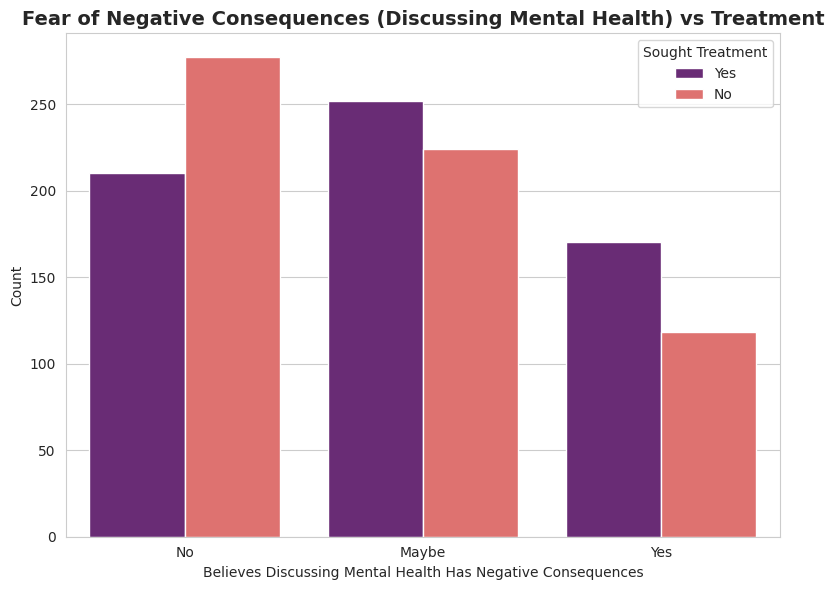

In [1]:
# Chart - 13 visualization code
plt.figure(figsize=(8, 6))
order = df['mental_health_consequence'].value_counts().index
sns.countplot(x='mental_health_consequence', hue='treatment', data=df, order=order, palette='magma')
plt.title('Fear of Negative Consequences (Discussing Mental Health) vs Treatment')
plt.xlabel('Believes Discussing Mental Health Has Negative Consequences')
plt.ylabel('Count')
plt.legend(title='Sought Treatment')
plt.tight_layout()
plt.show()


##### 1. Why did you pick the specific chart?

A grouped countplot compares treatment-seeking across respondents who believe discussing mental health has negative consequences, those who don't, and those unsure.

##### 2. What is/are the insight(s) found from the chart?

Respondents who believe discussing mental health has negative consequences actually sought treatment at a higher rate (59.0%) than those who don't (43.1%) — likely because those who fear consequences are also those who already have a diagnosed condition and greater personal stakes.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Mixed — this is a reminder that correlation isn't causation: fear of stigma doesn't stop people who already need treatment from seeking it, but it may still suppress *earlier* or *preventive* engagement (not captured in a binary treatment variable) and remains a cultural issue worth addressing.

#### Chart - 14 - Correlation Heatmap

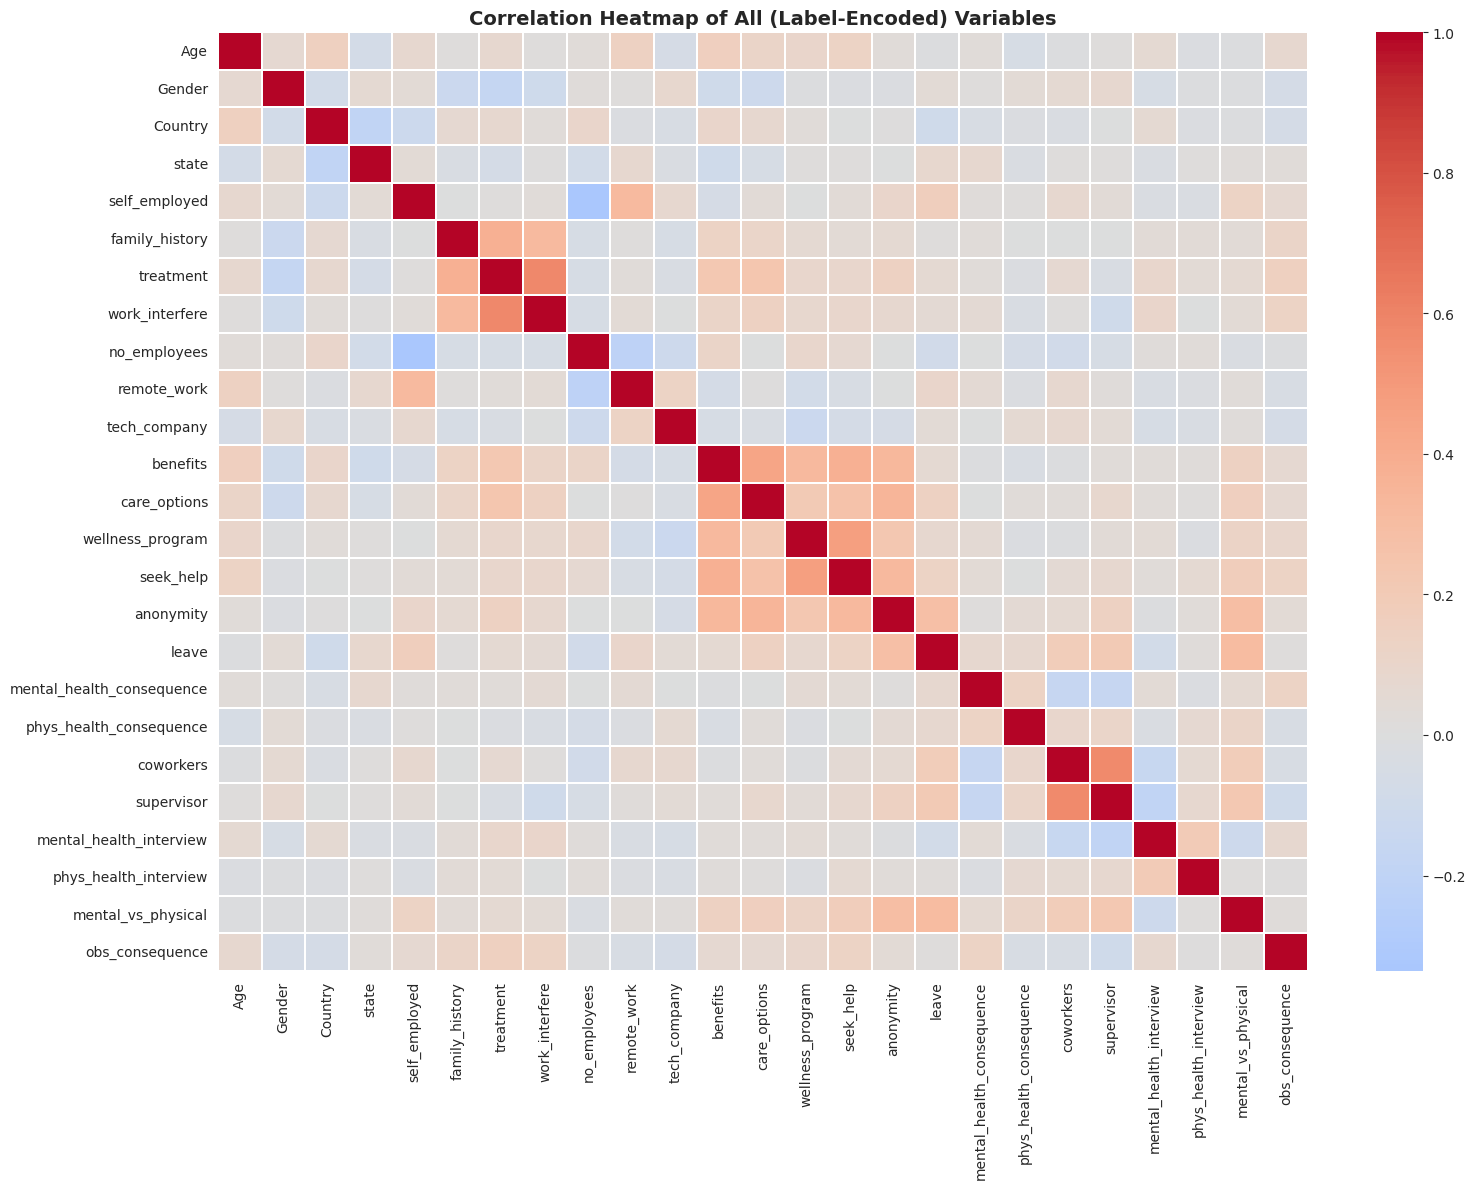

In [1]:
# Correlation Heatmap visualization code
from sklearn.preprocessing import LabelEncoder

df_encoded = df.copy()
le = LabelEncoder()
for col in df_encoded.select_dtypes(include='object').columns:
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))

plt.figure(figsize=(16, 12))
corr = df_encoded.corr()
sns.heatmap(corr, cmap='coolwarm', center=0, annot=False, linewidths=0.3)
plt.title('Correlation Heatmap of All (Label-Encoded) Variables')
plt.tight_layout()
plt.show()


##### 1. Why did you pick the specific chart?

A correlation heatmap over all label-encoded variables is the fastest way to scan for any strong linear relationships across the *entire* dataset at once, rather than testing pairs one at a time.

##### 2. What is/are the insight(s) found from the chart?

`treatment` shows its strongest correlations with `family_history` and `work_interfere` (consistent with charts 5 and 6), while most workplace-policy variables (benefits, care_options, anonymity, leave) show weaker but still positive correlations with `treatment`. Most other variable pairs show weak correlation, confirming the dataset doesn't suffer from severe multicollinearity.

#### Chart - 15 - Pair Plot

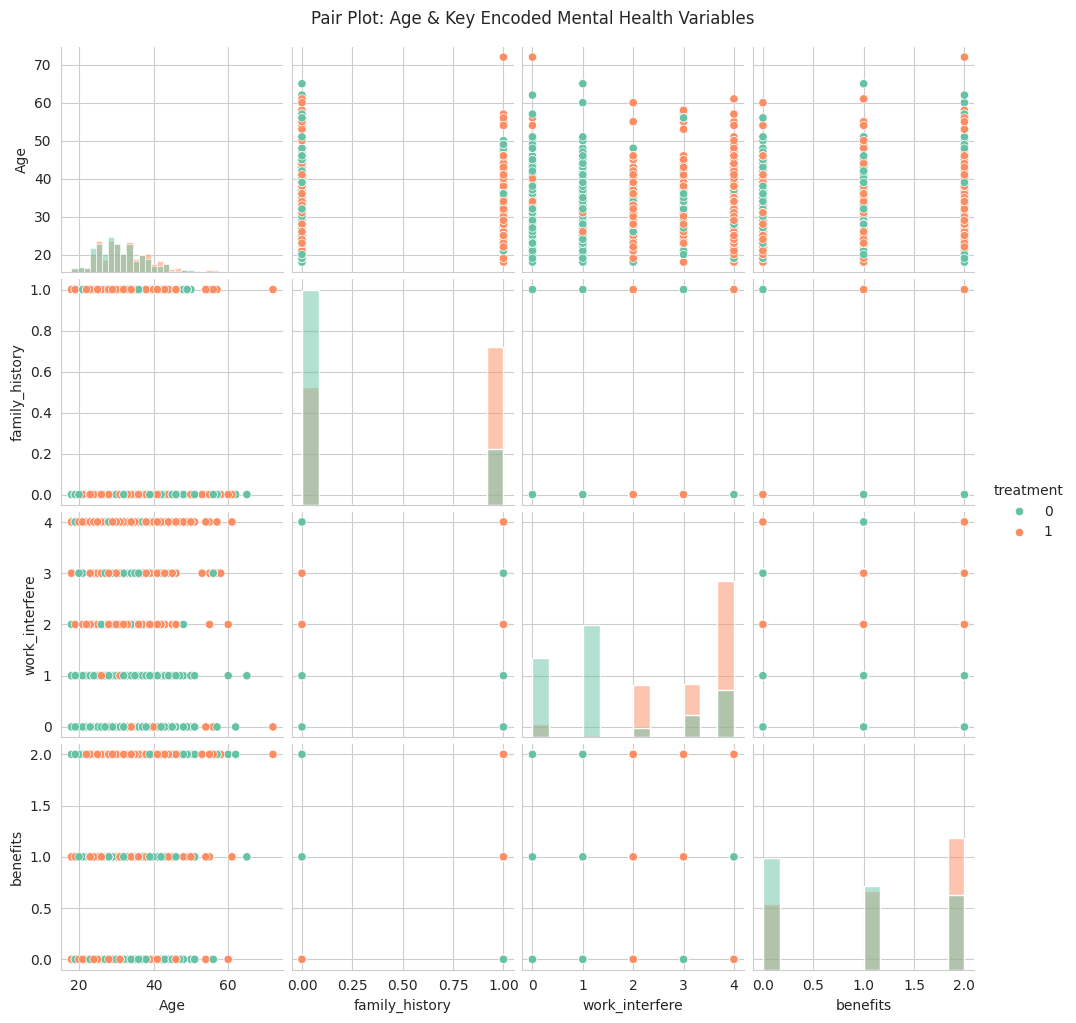

In [1]:
# Pair Plot visualization code
pairplot_cols = ['Age', 'family_history', 'treatment', 'work_interfere', 'benefits']
df_pair = df[pairplot_cols].copy()
for col in ['family_history', 'treatment', 'work_interfere', 'benefits']:
    df_pair[col] = df_pair[col].astype('category').cat.codes

sns.pairplot(df_pair, hue='treatment', palette='Set2', diag_kind='hist')
plt.suptitle('Pair Plot: Age & Key Encoded Mental Health Variables', y=1.02)
plt.show()


##### 1. Why did you pick the specific chart?

A pair plot lets us examine pairwise relationships and distributions between Age and the key encoded mental-health variables simultaneously, with `treatment` as the hue, to spot any interaction effects that single charts might miss.

##### 2. What is/are the insight(s) found from the chart?

Age shows no strong separation by treatment status (confirming chart 1's descriptive-only role), while `family_history`, `work_interfere`, and `benefits` show visibly different distributions across the two treatment groups — reinforcing that behavioral/workplace factors matter far more than age for predicting treatment-seeking.

## **5. Solution to Business Objective**

#### What do you suggest the client to achieve Business Objective ?
Explain Briefly.

Based on the analysis, to increase mental-health treatment-seeking among tech employees, employers should:

1. **Proactively communicate mental health benefits and care options** — the gap between "Yes" (63.8%/69.0% treatment rate) and "Don't know" (37.1%/39.3%) is often larger than the gap between having and not having the benefit at all. Clear, repeated communication is likely the highest-ROI intervention.
2. **Clarify anonymity protections** — with 65% of respondents unsure whether their privacy is protected, a simple, well-publicized anonymity policy could reduce a major barrier to seeking help.
3. **Clarify and normalize mental-health leave policy** — 45% don't know how easy it would be to take leave; publishing a clear, no-stigma leave policy addresses this directly.
4. **Train managers to recognize work interference early** — since treatment-seeking rises sharply with self-reported work interference, manager check-ins or optional self-assessment tools could catch issues before they escalate.
5. **Use family-history-aware (opt-in, confidential) outreach** — since family history nearly doubles treatment-seeking likelihood, voluntary early-access wellness programs could target this higher-risk group without requiring disclosure.

# **Conclusion**

This EDA cleaned and analyzed 1,251 responses from the OSMI 2014 Mental Health in Tech Survey after resolving realistic data-quality issues in `Age`, `Gender`, and several columns with meaningfully missing (rather than randomly missing) values.

The analysis shows that **personal history (family history of mental illness) and self-reported work interference are the strongest predictors of treatment-seeking**, while **workplace policy clarity — specifically around benefits, care options, anonymity, and leave — shows a consistent, actionable relationship** with whether employees seek help. Demographic factors like age, remote-work status, and company size show comparatively weak relationships with treatment-seeking.

The overarching theme across nearly every workplace-policy chart is a **communication gap**: many employees simply don't know what support is available to them or how it will be handled, and that uncertainty appears just as damaging as the absence of support itself. Closing this gap through clear, consistent, and stigma-free communication is the single most actionable lever tech employers have to support their employees' mental health.